In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

import os

import zglitchfunc as gf

## Lets apply tSNE in all O3a run

### Read the data

Read and apply filters to triggers
  
* To see the lenght, in CMD use: **wc -l arquivename.csv**
* To see the columns, in CMD use: **head -n 1 arquivename.csv**

In [2]:
run = 'O3a'

In [3]:
tperc, gperc = 0.7, 1.0
trigg_size, glit_size = 359385802, 187770

trigcols = ['time', 'frequency', 'snr']
glitcols = ['GPStime', 'centralFreq', 'snr', 'label', 'confidence']

ntrig, nglit = int(trigg_size*tperc), int(glit_size*gperc)

filter1000 = True

The following we will performs a random and filtered read of a large CSV file to save memory

In [4]:
gdchar_source = '/home/esanches/Projetos/tSNE/Virgo/'

In [5]:
np.random.seed(42)
skip_logic = lambda i: i > 0 and np.random.random() > tperc
trigg = pd.read_csv(gdchar_source + 'triggers_total.csv', skiprows=skip_logic, usecols=trigcols)
trigg = trigg.sort_values('time').reset_index(drop=True)

unclustered = trigg.copy()

In [6]:
np.save('/home/esanches/Projetos/tSNE/Virgo/zrepository/' + run + '/unclustered.npy', unclustered)
unclustered.tail(5)

,time,frequency,snr
251583700,1.269672e+09,1426.656564,6.905275
251583701,1.269672e+09,474.735572,55.750837
251583702,1.269672e+09,1280.344030,8.660046
251583703,1.269672e+09,1079.892919,15.370766
251583704,1.269672e+09,879.323062,19.674751


and for glitches

In [8]:
glit = pd.read_csv(gdchar_source + 'gspy' + run + '.csv', usecols=glitcols)

glit = glit.drop(glit[glit['label'].isin(['None_of_the_Above', 'No_Glitch'])].index)
glit = glit[glit['confidence'] >= 0.9]

top10 = glit['label'].value_counts().head(10).index
glit = glit[glit['label'].isin(top10)].copy()

glit = glit.sort_values(by=[glitcols[0]]).reset_index(drop=True)

if filter1000 == True:
    limited_glit = glit.groupby('label', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42))

    limited_glit = limited_glit.sort_values(by=[glitcols[0]]).reset_index(drop=True)
    clustered = limited_glit.copy()
else:
    clustered = glit.copy()

In [9]:
np.save('/home/esanches/Projetos/tSNE/Virgo/zrepository/' + run + '/clustered.npy', clustered)
clustered.tail(5)

,GPStime,snr,centralFreq,confidence,label
8832,1.253967e+09,8.355,30.352,1.000,Scattered_Light
8833,1.253971e+09,7.899,20.195,0.998,Low_Frequency_Lines
8834,1.253973e+09,7.946,26.140,0.960,Low_Frequency_Burst
8835,1.253974e+09,12.798,592.631,1.000,Scattered_Light
8836,1.253975e+09,7.619,3909.822,0.991,Low_Frequency_Lines


### Glitchgram creation

Select the **dt** window around the glitch a

In [10]:
savepath = '/home/esanches/Projetos/tSNE/Virgo/zrepository/' + run + '/'
arq_name = 'gspy'
dt = 2

In [11]:
vecs, labs, GPSs = gf.glitch_to_glitchgram(unclustered, clustered, savepath, arq_name, deltat=dt, fmin=3, fmax=8192, tbins=41, fbins=30)

### tSNE plots

In [12]:
readpath = '/home/esanches/Projetos/tSNE/Virgo/zrepository/' + run + '/'
final_vecs = np.load(readpath + 'vecs_gspy_dt2.npy')
final_labs = np.load(readpath + 'labs_gspy_dt2.npy')
final_GPSs = np.load(savepath + 'GPSs_gspy_dt2.npy')

tsne = TSNE(n_components=2, n_jobs=-1, verbose=0, perplexity=30, learning_rate=200, 
            max_iter=1000, metric="euclidean", random_state=0)
proj = tsne.fit_transform(final_vecs)

proj_df = pd.DataFrame(proj, columns=['x axis', 'y axis'])
labs_df = pd.DataFrame(final_labs, columns=['label'])

cmap = plt.colormaps["tab10"]
le = LabelEncoder()
labels = le.fit_transform(labs_df.values.ravel())

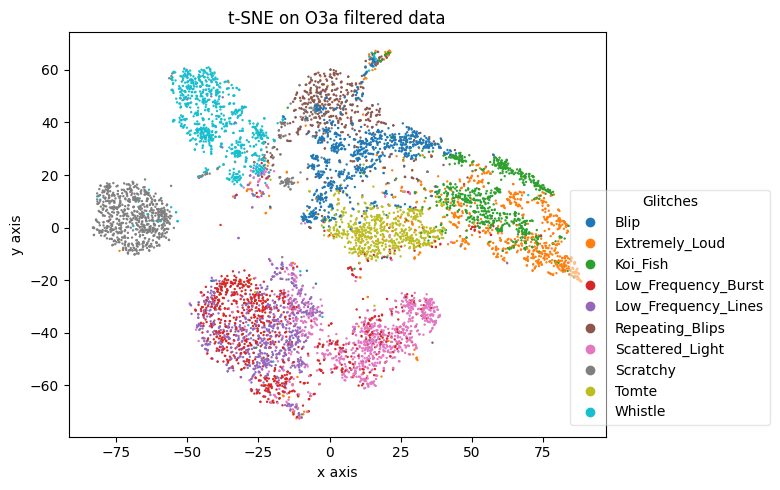

In [13]:
plt.figure(figsize=(8, 5))

sc = plt.scatter(proj_df.values[:,0], proj_df.values[:,1], s=0.5, c=labels, cmap=cmap)
plt.legend(handles=sc.legend_elements()[0], labels=list(le.classes_), title="Glitches", loc='center', framealpha=0.5, markerscale=1.0, bbox_to_anchor=(1.12, 0.32))

plt.title(f't-SNE on O3a filtered data')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.tight_layout()
plt.show()

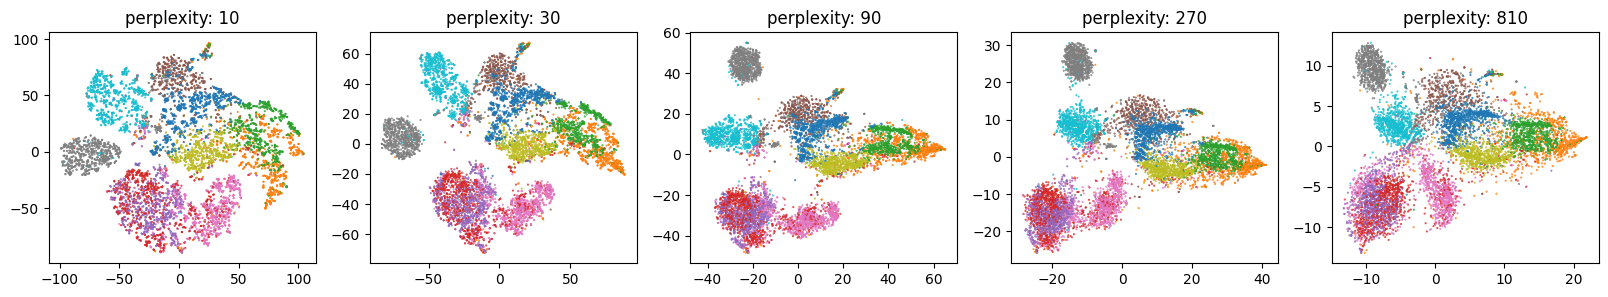

In [57]:
pxs = [10, 30, 90, 270, 810]
fig, axs = plt.subplots(1, len(pxs), figsize=(4*len(pxs), 3))

for i, p in enumerate(pxs):
    
    tsne = TSNE(n_components=2, n_jobs=-1, verbose=0, perplexity=p, learning_rate=200, 
            max_iter=1000, metric="euclidean", random_state=0)

    proj = tsne.fit_transform(final_vecs)
    proj_df = pd.DataFrame(proj, columns=['x axis', 'y axis'])
    labs_df = pd.DataFrame(final_labs, columns=['label'])

    axs[i].set_title(f'perplexity: {p}')
    axs[i].scatter(proj_df.values[:,0], proj_df.values[:,1], s=0.2, c=labels, cmap=cmap)

plt.show()

We observe that for this datast, a good value of perplexity is around 100

### Analysis by month

In [14]:
readpath = '/home/esanches/Projetos/tSNE/Virgo/zrepository/' + run + '/'

In [15]:
final_vecs = np.load(readpath + 'vecs_gspy_dt2.npy')
final_labs = np.load(readpath + 'labs_gspy_dt2.npy')
final_GPSs = np.load(readpath + 'GPSs_gspy_dt2.npy')

In [17]:
tsne = TSNE(n_components=2, n_jobs=-1, verbose=0, perplexity=200, learning_rate=200, 
            max_iter=1000, metric="euclidean", random_state=0)

proj = tsne.fit_transform(final_vecs)
proj_df = pd.DataFrame(proj, columns=['x axis', 'y axis'])

In [40]:
labs = pd.DataFrame(final_labs).rename(columns={0 : 'vecs'})
GPSs = pd.DataFrame(final_GPSs).rename(columns={0 : 'GPSs'})

o3a_intervals = {
    'Apr':    (1238166018, 1240761618),
    'May':     (1240761618, 1243440018),
    'Jun':    (1243440018, 1246032018),
    'Jul':    (1243440018, 1248710418),
    'Aug':   (1248710418, 1251388818),
    'Sep': (1251388818, 1253980818)
}

gps_1d = np.array(GPSs).ravel()
labs = np.array(labs).ravel()

In [74]:
projs_count = []

for m, (t_start, t_end) in o3a_intervals.items():

    mask = (gps_1d >= t_start) & (gps_1d < t_end)

    globals()[f"proj_{m.lower()}"] = pd.DataFrame({
    'tsne_1': proj_df.iloc[mask, 0],
    'tsne_2': proj_df.iloc[mask, 1],
    'label': labs[mask],
    'GPStime': gps_1d[mask]
    })

    projs_count.append(mask.sum())

    print(f"proj_{m.lower()} ({mask.sum()} projections)")

proj_apr (1781 projections)
proj_may (920 projections)
proj_jun (724 projections)
proj_jul (2469 projections)
proj_aug (1637 projections)
proj_sep (1314 projections)


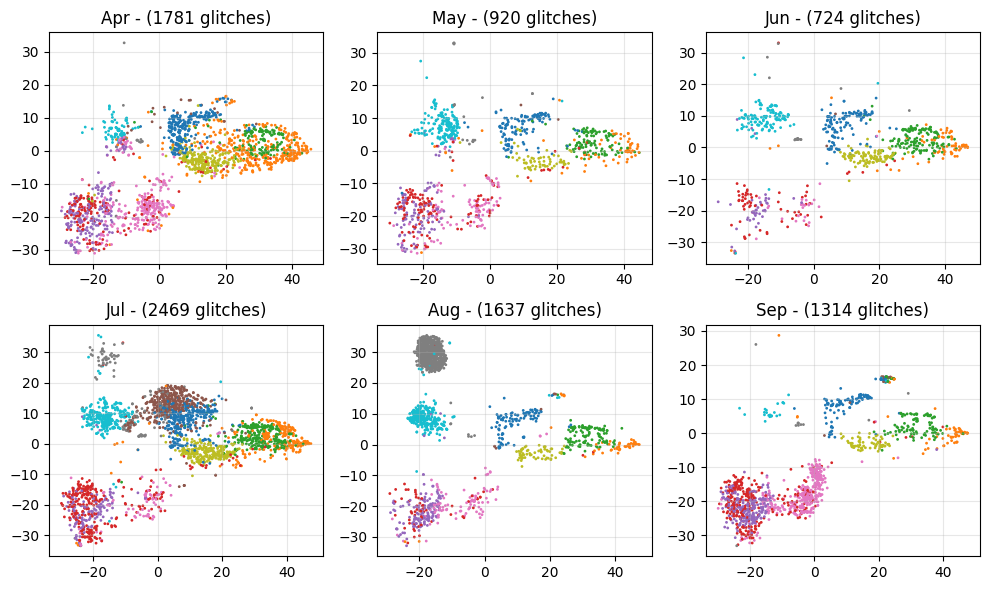

In [81]:
fig, axs = plt.subplots(2, 3, figsize=(10, 6))
axs = axs.ravel()

months = o3a_intervals.keys()

le = LabelEncoder()
le.fit(labs)

for i, m in enumerate(months):

    proj = globals()[f"proj_{m.lower()}"]
    
    cores = le.transform(proj['label'])
    
    axs[i].scatter(proj["tsne_1"], proj["tsne_2"], c=cores, cmap="tab10", s=1)
    axs[i].set_title(f'{m} - ({projs_count[i]} glitches)')
    axs[i].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

We can see that the 

### LLS glitches